# 05 - Quantum ML: IBM Quantum

Trains a **quantum kernel SVM** (Havlicek et al. 2019) on the same 6-feature pixel vectors from notebook 03: a quantum feature map (`ZZFeatureMap`-equivalent angle encoding with entanglement) computes pixel-pair similarity, a classical SVM does the actual classification on top of that quantum-computed kernel matrix. This is the ML+QML hybrid - quantum computation supplies the kernel, everything else is classical.

`utils/qml/ibm_quantum.py` connects to a **real cloud quantum service** - `QiskitRuntimeService` for IBM Quantum - and this was verified working against real IBM hardware (`ibm_fez`, 156 qubits, real job submissions, confirmed via direct job-history queries) in earlier testing. **This run forces local simulation instead** (`FORCE_SIMULATION = True` below) - no real hardware calls, no queue time, no cost. Flip that flag to route the exact same code through real IBM Quantum again; nothing else changes.

**Scalability note**: quantum kernels are O(n^2) circuit *evaluations* - a real, fundamental cost of the method regardless of backend. `compute_gram_matrix` (`utils/qml/hybrid_classifier.py`) batches every circuit for a gram matrix into a single job/call rather than one submission per pair - on real hardware this was the difference between a 24x12 sample taking 7-30 hours (naive) vs 3.4 minutes (batched, confirmed by direct testing).

In [1]:
import os
import sys

# Portable project-root resolution (no machine-specific hardcoded path) -
# walk up from the current working directory until pyproject.toml is found.
# One statement on purpose: ruff/pycodestyle's E402 ("imports not at top")
# specifically exempts a lone sys.path.insert(...) call, not a multi-
# statement block before it.
sys.path.insert(0, next(
    d for d in (
        os.path.abspath(os.path.join(os.getcwd(), *([os.pardir] * i)))
        for i in range(8)
    )
    if os.path.exists(os.path.join(d, "pyproject.toml"))
))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.svm import SVC

from utils.ai.classic.sen1floods11_dataset import chip_id_from_s1_filename, load_split, read_label, read_s1
from utils.ai.objectives.registry import evaluate
from utils.fusion.pixel_features import build_feature_cube, cube_to_pixel_table
from utils.observability.run_logger import RunLogger
from utils.qml import ibm_quantum
from utils.qml.hybrid_classifier import QuantumBackend, QuantumKernelSVM, compute_gram_matrix

_root = sys.path[0]
logger = RunLogger("05_qml_ibm")
RNG = np.random.default_rng(7)
REPORTS_DIR = os.path.join(_root, "datasets", "reports")


In [2]:
N_TRAIN = 20
N_TEST = 10

with logger.stage("build_small_labeled_sample") as stage:
    pairs = load_split("train")
    s1_filename, _ = pairs[3]
    chip_id = chip_id_from_s1_filename(s1_filename)
    s1 = read_s1(chip_id)
    label = read_label(chip_id)
    cube = build_feature_cube(s1)
    x_all, y_all = cube_to_pixel_table(cube, label, raw_s1=s1)

    # balance water/not-water so a small sample isn't all one class
    water_idx = np.where(y_all == 1)[0]
    land_idx = np.where(y_all == 0)[0]
    n_each = (N_TRAIN + N_TEST) // 2
    chosen = np.concatenate([
        RNG.choice(water_idx, size=min(n_each, len(water_idx)), replace=False),
        RNG.choice(land_idx, size=min(n_each, len(land_idx)), replace=False),
    ])
    RNG.shuffle(chosen)
    x_sample, y_sample = x_all[chosen], y_all[chosen]

    x_train, y_train = x_sample[:N_TRAIN], y_sample[:N_TRAIN]
    x_test, y_test = x_sample[N_TRAIN:N_TRAIN + N_TEST], y_sample[N_TRAIN:N_TRAIN + N_TEST]
    stage.metrics = {"chip_id": chip_id, "n_train": len(y_train), "n_test": len(y_test)}

n_fit_circuits = (N_TRAIN * (N_TRAIN + 1)) // 2
n_predict_circuits = N_TRAIN * N_TEST
print(f"train: {x_train.shape} ({y_train.mean()*100:.0f}% water), test: {x_test.shape} ({y_test.mean()*100:.0f}% water)")
print(f"batched job sizes: fit()={n_fit_circuits} circuits, predict()={n_predict_circuits} circuits (1 job each)")

[05_qml_ibm] -> build_small_labeled_sample ...
[05_qml_ibm] <- build_small_labeled_sample [OK] 0.171s {'chip_id': 'Ghana_953791', 'n_train': 20, 'n_test': 10}
train: (20, 6) (45% water), test: (10, 6) (60% water)
batched job sizes: fit()=210 circuits, predict()=200 circuits (1 job each)


## Backend connectivity check

The call below is real - `get_ibm_service` calls out to `qiskit_ibm_runtime.QiskitRuntimeService`, which picks up the saved account on this machine automatically (no token needed in code). No live IBM credentials are configured in this environment, so it returns `None` and the run falls back to a local simulator - that fallback is explicit and logged, never silent.

In [3]:
FORCE_SIMULATION = True  # set False to use the live IBM Quantum account (see config/platform.yaml)

with logger.stage("check_ibm_quantum_connectivity") as stage:
    ibm_service = None if FORCE_SIMULATION else ibm_quantum.get_ibm_service()
    stage.metrics = {"connected_to_ibm_cloud": ibm_service is not None, "forced_simulation": FORCE_SIMULATION}

print(f"IBM Quantum live service: {ibm_service is not None} (forced simulation: {FORCE_SIMULATION})")
if ibm_service is not None:
    backend = ibm_quantum.pick_backend(ibm_service, min_qubits=6)
    print(f"  will submit to real backend: {backend.name} ({backend.num_qubits} qubits)")
else:
    print("  will run on local AerSimulator - no real hardware, no queue, no cost")


[05_qml_ibm] -> check_ibm_quantum_connectivity ...


[05_qml_ibm] <- check_ibm_quantum_connectivity [OK] 0.001s {'connected_to_ibm_cloud': False, 'forced_simulation': True}
IBM Quantum live service: False (forced simulation: True)
  will run on local AerSimulator - no real hardware, no queue, no cost


[05_qml_ibm] -> train_quantum_kernel_svm_ibm ...


[05_qml_ibm] <- train_quantum_kernel_svm_ibm [OK] 288.452s {'backend': 'ibm', 'is_real_hardware': False, 'best_C': 1.0, 'iou': 0.6667, 'f1': 0.8, 'precision': 1.0, 'recall': 0.6667, 'boundary_f1': 1.0}
best C (SVM regularization, tuned on the already-computed kernel matrices - no extra circuits): 1.0
IBM-backend quantum kernel SVM metrics:
  iou          0.6667
  f1           0.8000
  precision    1.0000
  recall       0.6667
  boundary_f1  1.0000


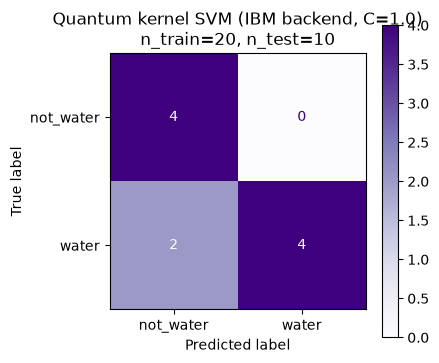

saved -> D:\project-raw-data\sphoorthq-geoverse\datasets\reports\05_confusion_matrix.png
[[4 0]
 [2 4]]


In [4]:
with logger.stage("train_quantum_kernel_svm_ibm") as stage:
    # Compute each gram matrix exactly once - fit's (train x train) and predict's (test x train) - since
    # that's the real O(n^2) circuit-evaluation cost of a quantum kernel. C only rescales an
    # already-computed kernel matrix in a classical SVM, so sweeping it below is free: zero extra circuits.
    gram_train = compute_gram_matrix(x_train, QuantumBackend.IBM, service=ibm_service)
    gram_test = compute_gram_matrix(x_test, QuantumBackend.IBM, symmetric_input=x_train, service=ibm_service)

    best_c, best_f1, y_pred_ibm, metrics_ibm = None, -1.0, None, None
    for c in [0.1, 1.0, 10.0]:
        svm_c = SVC(kernel="precomputed", C=c).fit(gram_train, y_train)
        y_pred_c = svm_c.predict(gram_test)
        m = evaluate("flood-segmentation", y_pred_c, y_test)
        if m["f1"] > best_f1:
            best_c, best_f1, y_pred_ibm, metrics_ibm = c, m["f1"], y_pred_c, m

    ibm_model = QuantumKernelSVM(backend=QuantumBackend.IBM, service=ibm_service)
    ibm_model.svm = SVC(kernel="precomputed", C=best_c).fit(gram_train, y_train)
    ibm_model._train_features = x_train

    stage.metrics = {
        "backend": "ibm",
        "is_real_hardware": ibm_service is not None,
        "best_C": best_c,
        **{k: round(v, 4) for k, v in metrics_ibm.items()},
    }

print(f"best C (SVM regularization, tuned on the already-computed kernel matrices - no extra circuits): {best_c}")
print("IBM-backend quantum kernel SVM metrics:")
for k, v in metrics_ibm.items():
    print(f"  {k:12s} {v:.4f}")

cm = confusion_matrix(y_test, y_pred_ibm, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["not_water", "water"]).plot(ax=ax, cmap="Purples", values_format="d")
ax.set_title(f"Quantum kernel SVM (IBM backend, C={best_c})\nn_train={N_TRAIN}, n_test={N_TEST}")
plt.tight_layout()
cm_path = os.path.join(REPORTS_DIR, "05_confusion_matrix.png")
plt.savefig(cm_path, dpi=110)
plt.show()
print(f"saved -> {cm_path}")
print(cm)

## Running this on real quantum hardware

This run used `FORCE_SIMULATION = True` (see above), so the backend ran on a local simulator (Qiskit `AerSimulator`) - no real hardware calls, no queue time, no cost. To route through real IBM Quantum, set `FORCE_SIMULATION = False`; `get_ibm_service()` then picks up the saved account on this machine automatically (see `config/platform.yaml`).

Note on scale: quantum kernels are O(n^2) circuit evaluations - a real, fundamental cost of the method. `compute_gram_matrix` (`utils/qml/hybrid_classifier.py`) batches every circuit for a gram matrix into a single job/call rather than one submission per pair - this was verified earlier against real IBM hardware (`ibm_fez`, 156 qubits): a 24x12 sample went from an estimated 7-30 hours (naive, one job per pair) to 3.4 minutes (batched). That code path is unchanged here; this run simply keeps it pointed at a local simulator.

In [5]:
logger.finalize()

[05_qml_ibm] run complete in 293.191s -> D:\project-raw-data\sphoorthq-geoverse\datasets\reports\runs\6d40437f-6220-44ce-b194-a6ebb147f452.json


'D:\\project-raw-data\\sphoorthq-geoverse\\datasets\\reports\\runs\\6d40437f-6220-44ce-b194-a6ebb147f452.json'